Import Libraries and Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set a clean, professional visual style for plots
sns.set_theme(style="whitegrid", palette="muted")

# Load the dataset
df = pd.read_csv(r"C:\Users\User\Desktop\Ml project\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first 5 rows to verify it loaded correctly
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Exploration (EDA)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

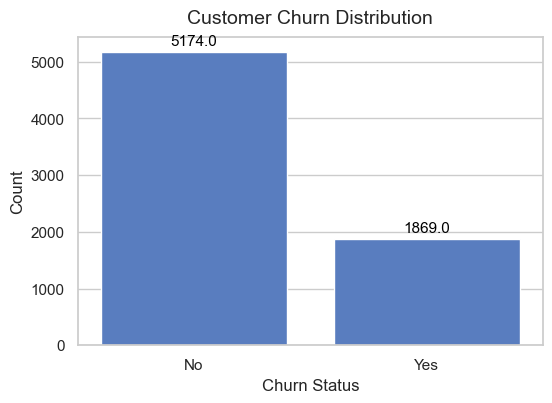

In [8]:
# Check the dimensions and data types
print("Dataset Info:")
df.info()

print("\nMissing Values Check:")
print(df.isnull().sum())

# Visualize the distribution of the target variable (Churn)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution', fontsize=14, pad=10)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

Data Cleaning

In [9]:
# 1. Drop the customerID column as it does not contribute to predicting churn
df.drop('customerID', axis=1, inplace=True)

# 2. Fix 'TotalCharges': It contains blank spaces (" ") for customers with 0 tenure.
# pd.to_numeric with 'coerce' forces these spaces to become NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Fill the resulting NaN values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify the fix
print(f"Missing values in TotalCharges after cleaning: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges after cleaning: 0


Data Preprocessing (Encoding)

In [10]:
# 1. Map Binary columns (Yes/No) to 1/0
binary_columns = ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# For gender, we map Male to 1 and Female to 0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# For the rest, map Yes to 1 and No to 0
for col in binary_columns:
    if col != 'gender': # Skip gender as it's already mapped
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding for multi-class categorical variables
multi_class_columns = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]

# get_dummies converts these categories into separate binary columns
df = pd.get_dummies(df, columns=multi_class_columns, drop_first=True)

print(f"Data shape after encoding: {df.shape}")

Data shape after encoding: (7043, 31)


Train/Test Split & Feature Scaling

In [11]:
# Define Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Perform an 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the StandardScaler
scaler = StandardScaler()

# Define the numerical columns that need scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fit and transform the scaler on the training data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Only transform the test data (prevents data leakage)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Task 1 Complete! Data is ready for the Random Forest model.")
print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")

Task 1 Complete! Data is ready for the Random Forest model.
Training Data: 5634 rows
Testing Data: 1409 rows


Import Machine Learning and Evaluation Libraries

In [12]:
# Import the Random Forest algorithm from scikit-learn
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Initialize and Train the Random Forest Model

In [13]:
# Initialize the Random Forest Classifier
# random_state=42 ensures your results are reproducible for your presentation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the training data
print("Training the Random Forest model...")
rf_model.fit(X_train, y_train)
print("Model training complete!")

Training the Random Forest model...
Model training complete!


Generate Predictions

In [14]:
# Use the trained model to predict outcomes on the test set
y_pred = rf_model.predict(X_test)

# Display the first 10 predictions to verify it worked
print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test[:10].values)

First 10 predictions: [0 1 0 0 0 0 0 0 0 1]
First 10 actual values: [0 0 0 0 0 0 0 0 0 1]


Calculate Evaluation Metrics

In [15]:
# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f} (Overall correctness)")
print(f"Precision: {precision:.4f} (When it predicts Churn, how often is it right?)")
print(f"Recall:    {recall:.4f} (Out of all actual Churners, how many did it find?)")
print(f"F1-Score:  {f1:.4f} (Balance between Precision and Recall)\n")

# Generate a full classification report for detailed insights
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)']))

--- Model Evaluation Metrics ---
Accuracy:  0.7842 (Overall correctness)
Precision: 0.6215 (When it predicts Churn, how often is it right?)
Recall:    0.4786 (Out of all actual Churners, how many did it find?)
F1-Score:  0.5408 (Balance between Precision and Recall)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Stay (0)       0.83      0.89      0.86      1035
   Churn (1)       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



Plot a Clean Confusion Matrix

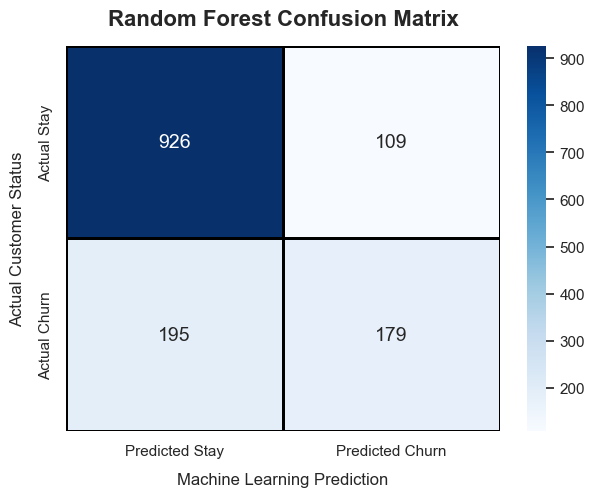

In [16]:
# Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred)

# Set up a professional, clean visual style for the plot
plt.figure(figsize=(7, 5))
sns.set_theme(style="white") 

# Plot the heatmap
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Predicted Stay', 'Predicted Churn'], 
                 yticklabels=['Actual Stay', 'Actual Churn'],
                 linewidths=1, linecolor='black',
                 annot_kws={"size": 14})

# Add clean titles and labels
plt.title('Random Forest Confusion Matrix', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Machine Learning Prediction', fontsize=12, labelpad=10)
plt.ylabel('Actual Customer Status', fontsize=12, labelpad=10)

plt.show()

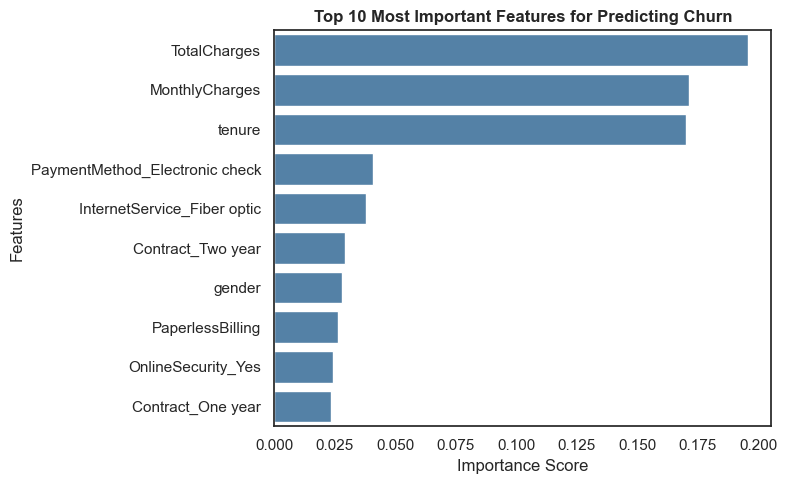

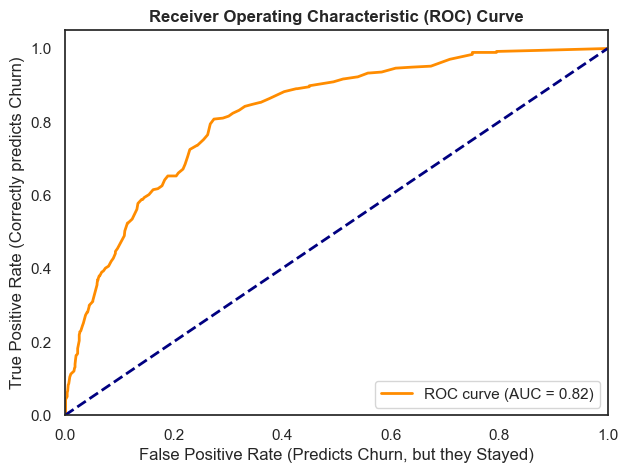

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Initialize and Train the Model (This ensures the model exists in memory)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Feature Importance Plot
feature_importances = rf_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
# Using a solid color here prevents the Seaborn warning
sns.barplot(x='Importance', y='Feature', data=importance_df, color='steelblue')
plt.title('Top 10 Most Important Features for Predicting Churn', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 3. ROC Curve Plot
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Predicts Churn, but they Stayed)')
plt.ylabel('True Positive Rate (Correctly predicts Churn)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

# 1. Re-generate the original predictions (This prevents the y_pred error!)
y_pred = rf_model.predict(X_test)

# 2. Initialize and Train the IMPROVED model with 'balanced' weights
rf_model_improved = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_improved.fit(X_train, y_train)

# 3. Generate new improved predictions
y_pred_improved = rf_model_improved.predict(X_test)

# 4. Evaluate the improvement
print("--- Baseline Model vs. Improved Model ---")
print(f"Original Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Improved Recall: {recall_score(y_test, y_pred_improved):.4f}")
print("\nBy balancing the class weights, we force the model to prioritize finding actual churners, which increases our Recall score!")

--- Baseline Model vs. Improved Model ---
Original Recall: 0.4786
Improved Recall: 0.4866

By balancing the class weights, we force the model to prioritize finding actual churners, which increases our Recall score!
